In [1]:
import os
os.environ["JAX_PLATFORM_NAME"] = "gpu"
import netket as nk
import numpy as np
import netket as nk
import jax
print(jax.devices())
import jax.numpy as jnp
import jax.tree_util as tree
import jax.typing as jt
import matplotlib.pyplot as plt
import optax
import random
import time
from flax import nnx
from flax import linen as nn
from netket.experimental.observable import Renyi2EntanglementEntropy
from functools import partial
from tqdm import tqdm
from netket.jax import jacobian
from itertools import product
from typing import Callable, Sequence
from jax.flatten_util import ravel_pytree
from scipy.optimize import minimize

[CudaDevice(id=0)]


In [2]:
# Hilbert space
from netket.hilbert import Spin
N = 10
N_ancilla = 10

# System: N 1/2
# Ancilla: N_ancilla  1/2
# Total space = spin ⊗ ancilla
hi_system = nk.hilbert.Spin(s=1/2, N=N)
hi_ancilla = nk.hilbert.Spin(s=1/2, N=N_ancilla)
hi_extended = nk.hilbert.Spin(s=1/2, N=N+N_ancilla)

partition = list(range(N)) 

$\mathcal{H_0}=Γ \sum_{i}\sigma_i^{(x)}+V\sum_{i}\sigma_i^{(z)}\sigma_{i+1}^{z} \qquad \mathcal{H_R}=\mathbb{I}_R$

$\mathcal{H}=\mathcal{H_0}\otimes\mathbb{I}_R$

In [3]:
# Pauli matrices import, Hamiltonian  H = H_0 ⊗ I_R
from netket.operator.spin import sigmax, sigmaz
Gamma = -1.5  
V = -1
H_system=0
H_extended = 0

for i in range(N):
    H_system += Gamma * sigmax(hi_system, i)
    H_system += V * sigmaz(hi_system, i) @ sigmaz(hi_system, (i + 1) % N)

for i in range(N):
    H_extended += Gamma * sigmax(hi_extended, i)
    H_extended += V * sigmaz(hi_extended, i) @ sigmaz(hi_extended, (i + 1) % N)

$F_R=\langle H \rangle -TS_2$

Necesitamos una función que calcule $S_2$ y su gradiente. Utilizaremos:

$S_2=-\log(Tr(\rho_A^2))=-\log\left\langle\frac{\psi(r,\eta')\psi(r',\eta)}{\psi(r,\eta)\psi(r',\eta')}\right\rangle$

In [4]:
def renyi2_entropy_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    """
    Estima la entropía de entrelazamiento de Rényi-2 (S₂) mediante muestreo Monte Carlo
    usando el *swap trick*.

    Calcula:
        S₂ = -log( ⟨SWAP⟩ )

    donde ⟨SWAP⟩ es el valor esperado del operador swap que intercambia el subsistema
    `subsystem_sites` entre dos copias independientes del estado |ψ⟩.

    El valor esperado se estima estocásticamente a partir de muestras generadas con
    `vstate.sample`.

    Args:
        vstate : netket.vqs.MCState
            Estado variacional de NetKet que representa la función de onda |ψ⟩.

        N : int
            Número total de grados de libertad (spins/qubits).
            (Nota: actualmente no se usa explícitamente dentro de la función).

        subsystem_sites : array-like
            Índices de los sitios que definen el subsistema A.
            La entropía se calcula entre A y su complemento.

        n_samples : int
            Número de muestras Monte Carlo usadas para estimar ⟨SWAP⟩.
            Se generan 2 * n_samples configuraciones en total.

        key : int, optional
            Semilla para la permutación aleatoria de las muestras (JAX PRNG key).
            Default: 0.

        debug : bool, optional
            Si True, imprime información detallada sobre:
            - muestras generadas
            - configuraciones intercambiadas
            - valores medios de log |ψ|
            - estimación de ⟨SWAP⟩

    Returns:
       S2 : jax.numpy.DeviceArray
        Estimación Monte Carlo de la entropía de Rényi-2 del subsistema definido
        por `subsystem_sites`.

    """

    # Asegurar que subsystem_sites es un array de enteros
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)

    # Muestras
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    if debug:
      print(f"Samples1 shape: {samples1.shape}, Samples2 shape: {samples2.shape}")
      # print(f"All samples: " {all_samples})
      print(f"Samples1: {samples1}")
      print(f"Samples2: {samples2}")

    # Calcular el complementario
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)


    # Intercambio de subsistemas
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    if debug:
      print(f"Swapped1 shape: {swapped1.shape}, Swapped2 shape: {swapped2.shape}")
      print(f"Swapped1: {swapped1}")
      print(f"Swapped2: {swapped2}")

    # Log amplitudes de las configuraciones originales y permutadas
    log_psi_orig1 = vstate.log_value(samples1)
    log_psi_orig2 = vstate.log_value(samples2)
    log_psi_swap1 = vstate.log_value(swapped1)
    log_psi_swap2 = vstate.log_value(swapped2)
    if debug:
      # print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)), "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)))
      print("log|ψ(x)|² medio:", jnp.mean(jnp.abs(log_psi_orig1)).item(),  "log|ψ(y)|² medio:", jnp.mean(jnp.abs(log_psi_orig2)).item())
      print("log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap1)).item(), "log|ψ(swapped)|² medio:", jnp.mean(jnp.abs(log_psi_swap2)).item())

    # ⟨SWAP⟩ = ⟨ψ(x')ψ(y') / [ψ(x)ψ(y)]⟩
    swap_ratio = jnp.exp((log_psi_swap1 + log_psi_swap2) - (log_psi_orig1 + log_psi_orig2))
    swap_exp = jnp.mean(swap_ratio)
    if debug:
      jax.debug.print("swap ratio = {}", jnp.round(swap_ratio, 4))
      print(f"⟨SWAP⟩ = {swap_exp.item()}")

    # Entropía de Rényi 2
    S2 = -jnp.log(jnp.abs(swap_exp))
    return S2

def renyi2_entropy_and_grad_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    """
    Calcula la entropía de Rényi-2 de un subsistema y su gradiente mediante el *swap trick*
    
    Args:
        vstate: estado variacional de NetKet
        subsystem_sites: índices del subsistema
        n_samples: número de muestras
        key: semilla aleatoria
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2
        grad_S2: gradiente respecto a parámetros (misma estructura que vstate.parameters)
    """
    
    # ============================================================
    # 1) MUESTREO
    # ============================================================
    all_samples = vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=1000).reshape(-1, vstate.hilbert.size)
    key = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(key, all_samples, axis=0)
    
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:2*n_samples]
    
    # ============================================================
    # 2) CONFIGURACIONES SWAP
    # ============================================================
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
    
    # ============================================================
    # 3) LOG-AMPLITUDES
    # ============================================================
    log_o1 = vstate.log_value(samples1)
    log_o2 = vstate.log_value(samples2)
    log_s1 = vstate.log_value(swapped1)
    log_s2 = vstate.log_value(swapped2)
    
    # ============================================================
    # 4) RATIO SWAP Y ENTROPÍA S₂
    # ============================================================
    R = jnp.exp(jnp.real(log_s1 + log_s2 - log_o1 - log_o2))
    R_mean = jnp.mean(R)
    S2 = -jnp.log(jnp.abs(R_mean))
    
    # ============================================================
    # 5) JACOBIANOS O_θ = ∂_θ log ψ
    # ============================================================
    O_o1 = jacobian(vstate._apply_fun, vstate.parameters, samples1,
                    model_state=vstate.model_state, mode="real", dense=True)
    O_o2 = jacobian(vstate._apply_fun, vstate.parameters, samples2,
                    model_state=vstate.model_state, mode="real", dense=True)
    O_s1 = jacobian(vstate._apply_fun, vstate.parameters, swapped1,
                    model_state=vstate.model_state, mode="real", dense=True)
    O_s2 = jacobian(vstate._apply_fun, vstate.parameters, swapped2,
                    model_state=vstate.model_state, mode="real", dense=True)
    
    R_exp = R.reshape(-1, 1)  # (n_samples, 1) para broadcasting
    
    # ============================================================
    # 6) TÉRMINO 1: dependencia explícita de R en θ
    #    ⟨R · ∇log R⟩ = ⟨R · 2(O_s1 + O_s2 - O_o1 - O_o2)⟩
    # ============================================================
    grad_log_R = O_s1 + O_s2 - O_o1 - O_o2  # (n_samples, n_params)
    term1 = 2.0 * jnp.mean(R_exp * grad_log_R, axis=0)  # (n_params,)

    # ============================================================
    # 7) TÉRMINO 2: dependencia de p(x)p(y) en θ 
    #    2⟨(R - ⟨R⟩) · (O_o1 + O_o2)⟩
    #    ∇log p(x)p(y) = 2(O_o1 + O_o2) porque p = |ψ|²
    # ============================================================
    R_centered = (R - R_mean).reshape(-1, 1)
    term2 = 2.0 * jnp.mean(R_centered * (O_o1 + O_o2), axis=0)  # (n_params,)

    # ============================================================
    # 8) ∇S₂ = -(term1 + term2) / ⟨R⟩
    # ============================================================
    grad_S2_flat = -(term1 + term2) / R_mean

    _, unravel = jax.flatten_util.ravel_pytree(vstate.parameters)
    grad_S2 = unravel(grad_S2_flat)

    if debug:
        print(f"⟨R⟩  = {float(R_mean):.6f}")
        print(f"S₂   = {float(S2):.6f}")
        print(f"||term1|| = {jnp.linalg.norm(term1):.6f}  (explícito)")
        print(f"||term2|| = {jnp.linalg.norm(term2):.6f}  (REINFORCE)")
        print(f"|∇S₂| = {jnp.linalg.norm(grad_S2_flat):.6f}")
    
    return S2, grad_S2

def renyi2_entropy_and_grad_lambda_integral(vstate, subsystem_sites, n_samples, n_lambda=10, key=0, debug=False):
    """
    Calcula S₂ y ∇S₂ usando el método de la λ-integral
    basado en Drut & Porter (2022)

    S₂ = - ∫₀¹ dλ ⟨ln R⟩_{P_λ}
    ∇S₂ = - ∫₀¹ [ ⟨∇lnR⟩_{P_λ} + λ·Cov_{P_λ}(lnR, ∇lnR) + 2⟨(lnR-⟨lnR⟩)(O_o1+O_o2)⟩_{P_λ} ] dλ
    """
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)
    key_obj = jax.random.PRNGKey(key)
    lambda_grid = jnp.linspace(0.0, 1.0, n_lambda)

    f_vals = []
    grad_f_vals = []

    for lam in lambda_grid:

        key_obj, subkey = jax.random.split(key_obj)

        # =====================================================
        # 1) MUESTREO
        # =====================================================
        all_samples = (
            vstate.sample(n_samples=2 * n_samples, n_discard_per_chain=500)
            .reshape(-1, vstate.hilbert.size)
        )
        all_samples = jax.random.permutation(subkey, all_samples, axis=0)

        samples1 = all_samples[:n_samples]
        samples2 = all_samples[n_samples:2 * n_samples]

        # =====================================================
        # 2) SWAP CONFIGS
        # =====================================================
        all_sites = jnp.arange(samples1.shape[1])
        complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)

        swapped1 = jnp.concatenate(
            [samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1
        )
        swapped2 = jnp.concatenate(
            [samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1
        )

        # =====================================================
        # 3) LOG-AMPLITUDES Y RATIO R
        # =====================================================
        log_o1 = vstate.log_value(samples1)
        log_o2 = vstate.log_value(samples2)
        log_s1 = vstate.log_value(swapped1)
        log_s2 = vstate.log_value(swapped2)

        log_R = jnp.real(log_s1 + log_s2 - log_o1 - log_o2)

        # =====================================================
        # 4) JACOBIANOS O_θ = ∂_θ log ψ
        # =====================================================
        O_o1 = jacobian(vstate._apply_fun, vstate.parameters, samples1,
                        model_state=vstate.model_state, mode="real", dense=True)
        O_o2 = jacobian(vstate._apply_fun, vstate.parameters, samples2,
                        model_state=vstate.model_state, mode="real", dense=True)
        O_s1 = jacobian(vstate._apply_fun, vstate.parameters, swapped1,
                        model_state=vstate.model_state, mode="real", dense=True)
        O_s2 = jacobian(vstate._apply_fun, vstate.parameters, swapped2,
                        model_state=vstate.model_state, mode="real", dense=True)

        # ∇ln R = 2*(O_s1 + O_s2 - O_o1 - O_o2)
        grad_lnR = 2.0 * (O_s1 + O_s2 - O_o1 - O_o2)  # (n_samples, n_params)

        # =====================================================
        # 5) PESOS P_λ ∝ p(x)p(y) R^λ
        # =====================================================
        log_weights = lam * log_R
        log_weights -= jax.nn.logsumexp(log_weights)
        weights = jnp.exp(log_weights)  # (n_samples,)

        w = weights.reshape(-1, 1)  # para broadcasting

        # =====================================================
        # 6) f(λ) = ⟨ln R⟩_λ
        # =====================================================
        f_lam = jnp.sum(weights * log_R)
        f_vals.append(f_lam)

        # =====================================================
        # 7) ⟨∇ln R⟩_λ
        # =====================================================
        mean_grad = jnp.sum(w * grad_lnR, axis=0)  # (n_params,)

        # =====================================================
        # 8) Covarianza: Cov_λ(lnR, ∇lnR)
        #    = ⟨lnR · ∇lnR⟩_λ - ⟨lnR⟩_λ · ⟨∇lnR⟩_λ
        # =====================================================
        lnR_exp = log_R.reshape(-1, 1)
        mean_lnR_grad = jnp.sum(w * lnR_exp * grad_lnR, axis=0)
        cov = mean_lnR_grad - f_lam * mean_grad  # (n_params,)

        # =====================================================
        # 9) TÉRMINO REINFORCE: dependencia de p(x)p(y) en θ
        #    2⟨(lnR - ⟨lnR⟩_λ)(O_o1 + O_o2)⟩_λ
        # =====================================================
        lnR_centered = (log_R - f_lam).reshape(-1, 1)
        grad_log_p = O_o1 + O_o2  # ∇log[p(x)p(y)] / 2, shape (n_samples, n_params)
        reinforce = 2.0 * jnp.sum(w * lnR_centered * grad_log_p, axis=0)  # (n_params,)

        # =====================================================
        # 10) ∇f(λ) = ⟨∇lnR⟩_λ + λ·Cov + REINFORCE
        # =====================================================
        grad_f_flat = mean_grad + lam * cov + reinforce  # (n_params,)
        grad_f_vals.append(grad_f_flat)

        if debug:
            ess = 1.0 / jnp.sum(weights ** 2)
            print(f"λ={float(lam):.3f} | f(λ)={float(f_lam):.6f} | "
                  f"||mean_grad||={jnp.linalg.norm(mean_grad):.4f} | "
                  f"||cov||={jnp.linalg.norm(cov):.4f} | "
                  f"||reinforce||={jnp.linalg.norm(reinforce):.4f} | "
                  f"ESS={float(ess):.1f}")

    # =====================================================
    # 11) INTEGRACIÓN TRAPECIO
    # =====================================================
    f_vals = jnp.array(f_vals)
    dlam = lambda_grid[1] - lambda_grid[0]

    S2 = -(dlam * (0.5 * f_vals[0] + jnp.sum(f_vals[1:-1]) + 0.5 * f_vals[-1]))

    flat_grads = jnp.stack(grad_f_vals)  # (n_lambda, n_params)
    grad_S2_flat = -(dlam * (0.5 * flat_grads[0] + jnp.sum(flat_grads[1:-1], axis=0) + 0.5 * flat_grads[-1]))

    _, unravel = jax.flatten_util.ravel_pytree(vstate.parameters)
    grad_S2 = unravel(grad_S2_flat)

    if debug:
        print(f"\nS₂ = {float(S2):.6f}")
        print(f"||∇S₂|| = {jnp.linalg.norm(grad_S2_flat):.6f}")

    return float(S2), grad_S2

def renyi2_entropy_exact(vstate, subsystem_sites):
    """
    Calcula la entropía de Rényi-2 de forma exadta usando matriz densidad.
    
    S2 = -ln(Tr(ρ_A^2))
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
    """
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # Obtener vector de estado completo
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    # print(f"Sistema total: {N} qubits")
    # print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
    # print(f"Subsistema B: {n_B} qubits")
    # print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # Identificar qubits del complemento
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Reorganizar la base para tener (A, B) ordenados
    # Convertir {-1,+1} a {0,1} para indexar
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Crear índices para reorganizar
    # Queremos: primero los qubits de A, luego los de B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir cada configuración a un índice único
    # Índice = suma de 2^i * bit_i
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir el vector de estado en forma matricial |ψ⟩ → ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # Matriz densidad del sistema completo: ρ = |ψ⟩⟨ψ|
    # No necesitamos construirla explícitamente para la traza parcial
    
    # Traza parcial sobre B: ρ_A = Tr_B(|ψ⟩⟨ψ|)
    # ρ_A[i,j] = Σ_k ψ[i,k] ψ*[j,k]
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    
    # Verificar que es hermítica y normalizada
    # print(f"\n|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f} (debe ser 1)")
    # print(f"Tr(ρ_A) = {jnp.trace(rho_A):.6f} (debe ser 1)")
    hermiticity_error = jnp.max(jnp.abs(rho_A - jnp.conj(rho_A.T)))
    # print(f"Error hermiticidad: {hermiticity_error:.2e}")
    
    # Calcular ρ_A^2
    rho_A_squared = rho_A @ rho_A
    
    # Pureza y entropía de Rényi-2
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    # print(f"\nTr(ρ_A²) = {purity:.6f} (pureza)")
    # print(f"S2 = -ln(Tr(ρ_A²)) = {S2:.6f}")
    
    # Información adicional: autovalores de ρ_A
    eigenvalues = jnp.linalg.eigvalsh(rho_A)
    eigenvalues = jnp.sort(eigenvalues)[::-1]  # Ordenar descendente
    # print(f"\nAutovalores de ρ_A:")
    # for i, eig in enumerate(eigenvalues):
    #     if eig.real > 1e-10:  # Mostrar solo los significativos
    #         print(f"  λ_{i} = {eig.real:.6f}")
    
    # Entropía de von Neumann (para comparar)
    # S_vN = -Tr(ρ_A ln ρ_A) = -Σ λ_i ln(λ_i)
    eigenvalues_clean = jnp.where(eigenvalues > 1e-10, eigenvalues, 1)  # Evitar log(0)
    S_vN = -jnp.sum(eigenvalues * jnp.log(eigenvalues_clean)).real
    # print(f"\nS_vN (von Neumann) = {S_vN:.6f} (para comparar)")
    
    return S2, rho_A

def renyi2_grad_exact(vstate, subsystem_sites, isFullSum=False):
    """
    Calcula el gradiente exacto de la entropía de Rényi-2 usando
    diferenciación automática sobre la función que calcula S₂ exactamente.
    
    Args:
        vstate: NetKet variational state
        subsystem_sites: lista de sitios del subsistema A
        
    Returns:
        S2: Entropía de Rényi-2
        grad_S2: gradiente exacto (misma estructura que vstate.parameters)
    """
    
    # Definir una función que solo depende de los parámetros
    def S2_func(params):
        # Crear un estado temporal con los parámetros dados
        if isFullSum:
            vstate_tmp = nk.vqs.FullSumState(hi_extended, vstate.model)
        else:
            vstate_tmp = nk.vqs.MCState(sampler=vstate.sampler,model=vstate.model,n_samples=vstate.n_samples,)
        vstate_tmp.parameters = params
        S2, _ = renyi2_entropy_exact(vstate_tmp, subsystem_sites)
        return S2
    
    # Usar value_and_grad de JAX para obtener S₂ y su gradiente
    S2, S2_grad = jax.value_and_grad(S2_func)(vstate.parameters)
    return S2, S2_grad

def vstate_to_vector(vstate):
    """
    Convierte un vstate de NetKet a un vector de estado completo.
    
    Args:
        vstate: NetKet variational state
        
    Returns:
        state_vector: Vector completo normalizado (2^N dimensiones)
        basis_states: Configuraciones correspondientes a cada entrada
    """
    N = vstate.hilbert.size
    
    # Generar todas las configuraciones posibles
    # NetKet usa {-1, +1} para spins
    all_configs = jnp.array(list(product([-1, 1], repeat=N)))
    
    # Obtener amplitudes
    log_psi = vstate.log_value(all_configs)
    psi = jnp.exp(log_psi)
    
    # Normalizar
    norm = jnp.sqrt(jnp.sum(jnp.abs(psi)**2))
    state_vector = psi / norm
    
    return state_vector, all_configs

def renyi2_entropy_and_grad_fullsum(vstate, subsystem_sites, debug=False):
    """
    Calcula la entropía de Rényi-2 y su gradiente usando la matriz de densidad reducida.
    Compatible con FullSumState.
    
    Args:
        vstate: estado variacional de NetKet (FullSumState)
        subsystem_sites: índices del subsistema A
        debug: modo depuración
    
    Returns:
        S2: entropía de Rényi-2 = -log(Tr(ρ_A^2))
        grad_S2: gradiente respecto a parámetros
    """
    from netket.jax import jacobian
    
    N = vstate.hilbert.size
    subsystem_sites = np.array(subsystem_sites, dtype=int)
    
    # =======================================
    # 1) OBTENER VECTOR DE ESTADO COMPLETO 
    # =======================================
    psi, basis = vstate_to_vector(vstate)
    
    # Dimensiones
    n_A = len(subsystem_sites)
    n_B = N - n_A
    dim_A = 2**n_A
    dim_B = 2**n_B
    
    if debug:
        print(f"Sistema total: {N} qubits")
        print(f"Subsistema A: {n_A} qubits (sitios {subsystem_sites})")
        print(f"dim(A) = {dim_A}, dim(B) = {dim_B}")
    
    # ============================
    # 2) REORGANIZAR COMO MATRIZ 
    # ============================
    all_sites = np.arange(N)
    complement_sites = np.setdiff1d(all_sites, subsystem_sites)
    
    # Convertir {-1,+1} a {0,1}
    basis_01 = ((basis + 1) // 2).astype(int)
    
    # Reorganizar: primero A, luego B
    reordered_sites = np.concatenate([subsystem_sites, complement_sites])
    basis_reordered = basis_01[:, reordered_sites]
    
    # Convertir a índices
    powers_A = 2**np.arange(n_A)[::-1]
    powers_B = 2**np.arange(n_B)[::-1]
    
    idx_A = (basis_reordered[:, :n_A] * powers_A).sum(axis=1)
    idx_B = (basis_reordered[:, n_A:] * powers_B).sum(axis=1)
    
    # Construir matriz ψ[i_A, i_B]
    psi_matrix = jnp.zeros((dim_A, dim_B), dtype=complex)
    psi_matrix = psi_matrix.at[idx_A, idx_B].set(psi)
    
    # =====================
    # 3) CALCULAR ρ_A Y S₂ 
    # =====================
    rho_A = psi_matrix @ jnp.conj(psi_matrix.T)
    rho_A_squared = rho_A @ rho_A
    purity = jnp.trace(rho_A_squared).real
    S2 = -jnp.log(purity)
    
    if debug:
        print(f"|ψ|² = {jnp.sum(jnp.abs(psi)**2):.6f}")
        print(f"Tr(ρ_A) = {jnp.trace(rho_A).real:.6f}")
        print(f"Tr(ρ_A²) = {purity:.6f}")
        print(f"S₂ = {S2:.6f}")
    
    # ========================
    # 4) CALCULAR GRADIENTE
    # ========================
    # Calcular jacobianos O = ∂log(ψ)/∂θ para todas las configuraciones
    O_all = jacobian(vstate._apply_fun, vstate.parameters, basis,
                     model_state=vstate.model_state, mode="real", dense=False)
    
    # ∂S₂/∂θ = -(1/Tr(ρ_A²)) * ∂Tr(ρ_A²)/∂θ
    # 
    # Tr(ρ_A²) = Σ_{i,j,k} ψ[i,k] ψ*[j,k] ψ[j,ℓ] ψ*[i,ℓ]
    #
    # ∂Tr(ρ_A²)/∂θ = 2 Re[Σ_{i,j,k} (∂ψ[i,k]/∂θ) ψ*[j,k] (ρ_A²)[j,i]]
    
    def compute_grad_for_leaf(O_leaf):
        """Calcula el gradiente para una hoja del árbol de parámetros"""
        param_shape = O_leaf.shape[1:]
        grad_accum = jnp.zeros(param_shape, dtype=jnp.complex128)
        
        n_configs = len(basis)
        
        for config_idx in range(n_configs):
            i_A = idx_A[config_idx]
            i_B = idx_B[config_idx]
            
            # ∂ψ[i_A, i_B]/∂θ = ψ[i_A, i_B] * O[config_idx]
            d_psi_dtheta = psi[config_idx] * O_leaf[config_idx]
            
            # Contribución: Σ_j ψ*[j, i_B] * (ρ_A²)[j, i_A]
            # Equivalente a: (ψ_matrix[:, i_B])† @ (ρ_A²)[:, i_A]
            contribution = jnp.conj(psi_matrix[:, i_B]) @ rho_A_squared[:, i_A]
            
            grad_accum = grad_accum + contribution * O_leaf[config_idx]
        
        return 2.0 * grad_accum.real
    
    grad_trace = jax.tree_util.tree_map(compute_grad_for_leaf, O_all)
    
    # ∂S₂/∂θ = -(1/Tr(ρ_A²)) * ∂Tr(ρ_A²)/∂θ
    grad_S2 = jax.tree_util.tree_map(
        lambda g: -g / purity,
        grad_trace
    )
    
    if debug:
        flat_grad = jax.tree_util.tree_leaves(grad_S2)
        grad_norm = jnp.sqrt(sum(jnp.sum(g**2) for g in flat_grad))
        print(f"|∇S₂| = {grad_norm:.6f}")
    
    return S2, grad_S2

In [ ]:
@partial(jax.jit, static_argnames=("apply_fun",))
def _renyi2_loss_and_grad(apply_fun, params, model_state,
                          samples1, samples2, swapped1, swapped2):
    """
    Calcula S2 y grad_S2 usando backprop en vez de jacobianos explícitos.
    Memoria: O(n_params) en vez de O(n_samples × n_params)
    """
    def log_psi(p, s):
        return apply_fun({"params": p, **model_state}, s)

    # S2
    log_o1 = log_psi(params, samples1)
    log_o2 = log_psi(params, samples2)
    log_s1 = log_psi(params, swapped1)
    log_s2 = log_psi(params, swapped2)
    R = jnp.exp(jnp.real(log_s1 + log_s2 - log_o1 - log_o2))
    S2 = -jnp.log(jnp.abs(jnp.mean(R)))

    # Gradiente via backprop
    def loss_fn(p):
        lo1 = log_psi(p, samples1)
        lo2 = log_psi(p, samples2)
        ls1 = log_psi(p, swapped1)
        ls2 = log_psi(p, swapped2)
        R_ = jnp.exp(jnp.real(ls1 + ls2 - lo1 - lo2))
        R_mean = jax.lax.stop_gradient(jnp.mean(R_))
        w = jax.lax.stop_gradient(R_ / R_mean)
        return -2.0 * jnp.mean(w * jnp.real(ls1 + ls2)) \
               +2.0 * jnp.mean(jnp.real(lo1 + lo2))

    grad_S2 = jax.grad(loss_fn)(params)

    return S2, grad_S2


@partial(jax.jit, static_argnames=("apply_fun",))
def _renyi2_loss_and_grad_fast(apply_fun, params, model_state,
                               samples1, samples2, swapped1, swapped2):

    variables = {"params": params, **model_state}

    def loss_fn(p):

        vars_ = {"params": p, **model_state}

        # evaluar todas las configs juntas
        configs = jnp.concatenate([
            samples1,
            samples2,
            swapped1,
            swapped2
        ], axis=0)

        logpsi = apply_fun(vars_, configs)

        n = samples1.shape[0]

        log_o1 = logpsi[:n]
        log_o2 = logpsi[n:2*n]
        log_s1 = logpsi[2*n:3*n]
        log_s2 = logpsi[3*n:]

        R = jnp.exp(jnp.real(log_s1 + log_s2 - log_o1 - log_o2))

        R_mean = jnp.mean(R)

        w = jax.lax.stop_gradient(R / R_mean)

        loss = -2.0 * jnp.mean(w * jnp.real(log_s1 + log_s2)) \
               + 2.0 * jnp.mean(jnp.real(log_o1 + log_o2))

        return loss, R_mean

    (loss, R_mean), grad = jax.value_and_grad(loss_fn, has_aux=True)(params)

    S2 = -jnp.log(jnp.abs(R_mean))

    return S2, grad

def renyi2_entropy_and_grad_sampled(vstate, subsystem_sites, n_samples, key=0, debug=False):
    subsystem_sites = jnp.array(subsystem_sites, dtype=int)

    # Muestreo (NetKet)
    all_samples = vstate.sample(
        n_samples=2 * n_samples, n_discard_per_chain=1000
    ).reshape(-1, vstate.hilbert.size)

    rng = jax.random.PRNGKey(key)
    all_samples = jax.random.permutation(rng, all_samples, axis=0)
    samples1 = all_samples[:n_samples]
    samples2 = all_samples[n_samples:]

    # Swap
    all_sites = jnp.arange(samples1.shape[1])
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
    swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)

    # S2 y gradiente via backprop
    S2, grad_S2 = _renyi2_loss_and_grad(
        vstate._apply_fun,
        vstate.parameters,
        vstate.model_state,
        samples1, samples2, swapped1, swapped2
    )

    if debug:
        grad_flat, _ = jax.flatten_util.ravel_pytree(grad_S2)
        print(f"S₂    = {float(S2):.6f}")
        print(f"|∇S₂| = {jnp.linalg.norm(grad_flat):.6f}")

    return S2, grad_S2

def renyi2_entropy_sampled(vstate, partition, n_samples):
    S2, _ = renyi2_entropy_and_grad_sampled(vstate, partition, n_samples)
    return float(S2)

In [6]:
#Modelo que fija gauge; MLP; modelo con simetría Z2, 

class GaugeFixedRBM(nn.Module):
    """
    Versión diferenciable usando codificación suave.
    Cada g(s_i,a_i) se parametriza con una matriz 2*2 pero sin índices enteros.
    """
    N: int
    alpha: int = 1

    def setup(self):
        # RBMs  para sistema y ancilla
        self.rbm_sys_anc = nk.models.RBM(alpha=self.alpha, param_dtype=jnp.float64)

        # Matriz 2x2 por sitio: J[i, s_val, a_val]
        self.J = self.param(
            "J",
            nn.initializers.normal(0.01),
            (self.N, 2, 2)
        )

    def __call__(self, sigma):
        s = sigma[..., :self.N]  # shape (batch, N)
        a = sigma[..., self.N:]  # shape (batch, N)

        # Forward RBMs
        log_psi_s = self.rbm_sys_anc(s)
        log_psi_a = self.rbm_sys_anc(a)

        # Codificación suave de spins: -1 -> [1,0], +1 -> [0,1]
        s0 = 0.5 * (1 - s)
        s1 = 0.5 * (1 + s)
        a0 = 0.5 * (1 - a)
        a1 = 0.5 * (1 + a)

        # coupling diferenciable
        # broadcasting: J shape (N,2,2), s0,s1,a0,a1 shape (batch,N)
        coupling = (
            self.J[:,0,0] * s0 * a0 +
            self.J[:,0,1] * s0 * a1 +
            self.J[:,1,0] * s1 * a0 +
            self.J[:,1,1] * s1 * a1
        )
        coupling = jnp.sum(coupling, axis=-1)  # suma sobre sitios

        log_psi = log_psi_s + log_psi_a + coupling

        # Estabilización opcional
        log_psi = jnp.clip(log_psi, -20.0, 20.0)
        return log_psi

REAL_DTYPE = jnp.asarray(1.0).dtype
class MultiLayerPerceptron(nn.Module):
    """Flax module for a Multi-layer perceptron architecture with normalization.

    Args:
        layer_widths: Sequence of integers that define both the number of layers
            and their widths.
        activation_funcion: The activation function that will be applied after
            each dense layer.
        kernel_init: Function to initialize the trainable parameters.

    Returns:
        A jax array with the output of the net.
    """

    layer_widths: Sequence[int]
    activation_function: Callable = nn.swish
    kernel_init: Callable = nn.initializers.lecun_normal()

    @nn.compact
    def __call__(self, x) -> jt.ArrayLike:
        for w in self.layer_widths:
            # We cannot use LayerNorm when the output has size 1, since
            # that would destroy the data.
            if w == 1:
                normalizer = lambda x: x
            else:
                normalizer = nn.LayerNorm(param_dtype=REAL_DTYPE)
            x = self.activation_function(
                normalizer(
                    nn.Dense(
                        w,
                        kernel_init=self.kernel_init,
                        param_dtype=REAL_DTYPE,
                    )(x)
                )
            )
        return x.squeeze(axis=-1)
    
class RBM_Z2(nn.Module):

    alpha: int = 1
    trivial_Z2: bool = False  # True → simetría (ψ(x)=ψ(-x)), False → antisimetría (ψ(x)=-ψ(-x))

    @nn.compact
    def __call__(self, x):
        # Definimos la RBM
        # worker = nk.models.RBM(alpha=self.alpha, param_dtype=float) 
        # worker = MultiLayerPerceptron(layer_widths=[8,16,8,1])
        worker = nk.models.ARNNDense(
            hilbert= nk.hilbert.Spin(s=1/2, N=N+N_ancilla),
            layers=1,           
            features=16,        
            activation=jax.nn.gelu,
            kernel_init=nn.initializers.variance_scaling(
                scale=0.05,  
                mode='fan_in',
                distribution='truncated_normal'
            ),
            bias_init=nn.initializers.constant(0.1)
        )
        # worker = GaugeFixedRBM(N, self.alpha)

        # Calculamos la log-amplitud para x y -x
        output_x = jnp.atleast_1d(worker(x))
        output_inv_x = jnp.atleast_1d(worker(-x))

        # Apilamos las dos
        z2_stack = jnp.stack([output_x, output_inv_x], axis=0)

        # Combinamos según el tipo de simetría
        if self.trivial_Z2:
            # Invariante (simétrica)
            res = jax.nn.logsumexp(z2_stack, axis=0)
        else:
            # Antisimétrica (cambia de signo)
            b = jnp.array([1.0, -1.0])[:, None]   #b es el coeficiente que precede a la exponencial. Por defecto = 1.0
            res = jax.nn.logsumexp(z2_stack, b=b, axis=0)

        return res
        # return nk.nn.log_cosh(res)

In [ ]:
#Comprobar que la derivada del gradiente funciona
#Se busca el estado que maximiza S₂, en nuestro caso max(S₂)=(N)*ln(2)

partition = list(range(N))  
sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
# sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=3008)
vstate.init_parameters
lr = 0.2
optimizer = optax.sgd(learning_rate=lr,momentum=0.9)

opt_state = optimizer.init(vstate.parameters)

S2_history_swap = []
S2_history_nk = []
S2_history_trace = []
S2_grad_history= []
s2_lambda_history = []

S2_obs = nk.experimental.observable.Renyi2EntanglementEntropy(hi_extended, partition=partition)

for step in range(1000):
    S2_nk = vstate.expect(S2_obs).mean.real*np.log(2)
    S2, S2_grad_2 = renyi2_entropy_and_grad_sampled(vstate, partition, vstate.n_samples)
    # S2, S2_grad_2 = renyi2_entropy_and_grad_reinforce(vstate, partition, vstate.n_samples)
    # S2, S2_grad_2 = renyi2_grad_exact(vstate, partition)
    # S2_lambda, S2_grad_2 = renyi2_entropy_and_grad_lambda_integral(vstate, partition, vstate.n_samples, 10)
    S2_trace = renyi2_entropy_exact(vstate, partition)[0]
    S2_grad = jnp.linalg.norm(jax.flatten_util.ravel_pytree(S2_grad_2)[0])
    
    S_grad = jax.tree_util.tree_map(
        lambda grad_S2:  - grad_S2,
        S2_grad_2
    )
    
    updates, opt_state = optimizer.update(S_grad, opt_state, vstate.parameters)
    vstate.parameters = optax.apply_updates(vstate.parameters, updates)

    S2_history_swap.append(S2)
    S2_history_nk.append(S2_nk)
    S2_history_trace.append(S2_trace)
    # s2_lambda_history.append(S2_lambda)
    S2_grad_history.append(S2_grad)
    
    if step % 20 == 0:
        grad_norm = jnp.linalg.norm(jax.flatten_util.ravel_pytree(S_grad)[0])
        print(f"Step {step}: S₂(SWAP)={S2:.6f}, S₂(NK)={S2_nk:.6f}, S₂(ρₛ)={S2_trace:.6f}, |∇S₂| = {S2_grad:.8f}")

plt.plot(S2_history_swap, label="SWAP", linewidth=0.6, alpha=0.7)
plt.plot(S2_history_nk, label="NetKet", linewidth=0.6, alpha=0.7)
plt.plot(S2_history_trace, label=r"$\rho_S$", linewidth=1.2)
# plt.plot(s2_lambda_history, label=r"$\lambda$", linewidth=0.6, alpha=0.9)
plt.plot(S2_grad_history, label=r"$|\nabla_\theta S_2$|", linewidth=0.6,)
plt.ylabel(r"$S_2$")
plt.ylim(0,)
plt.grid()
plt.legend()
plt.show

In [7]:
def visualize_s2_landscape(vstate, partition, optimal_params, n_samples=10000):
    """
    Visualiza el landscape de S₂ alrededor de los parámetros óptimos.
    
    Args:
        vstate: Estado variacional
        partition: Partición para calcular entrelazamiento
        optimal_params: Parámetros óptimos encontrados
        n_samples: Número de muestras para calcular S₂
    """
    
    # Aplanar parámetros completamente (incluyendo arrays internos)
    flat_params, tree_def = jax.tree_util.tree_flatten(optimal_params)
    
    # Aplanar completamente todos los arrays a escalares individuales
    all_scalars = []
    param_shapes = []
    param_indices = []  # (array_idx, element_idx)
    
    for i, param in enumerate(flat_params):
        if isinstance(param, (jnp.ndarray, np.ndarray)):
            param_flat = param.flatten()
            for j, scalar in enumerate(param_flat):
                all_scalars.append(float(scalar))
                param_shapes.append(param.shape)
                param_indices.append((i, j))
        else:
            all_scalars.append(float(param))
            param_shapes.append(())
            param_indices.append((i, -1))
    
    n_params = len(all_scalars)
    print(f"Número total de parámetros escalares: {n_params}")
    
    # Seleccionar dos parámetros escalares para explorar
    param_idx_1 = 0
    param_idx_2 = min(1, n_params - 1)
    
    # Definir rangos de exploración 
    param_1_opt = all_scalars[param_idx_1]
    param_2_opt = all_scalars[param_idx_2]
    
    range_factor = 10
    range_abs = max(abs(param_1_opt), 0.1)  # Evitar rangos de cero
    param_1_range = np.linspace(
        param_1_opt - range_factor * range_abs,
        param_1_opt + range_factor * range_abs,
        100
    )
    range_abs = max(abs(param_2_opt), 0.1)
    param_2_range = np.linspace(
        param_2_opt - range_factor * range_abs,
        param_2_opt + range_factor * range_abs,
        100
    )
    
    # ========== CORTE 2D ==========
    print("Generando landscape 2D...")
    S2_landscape = np.zeros((len(param_1_range), len(param_2_range)))
    
    for i, p1 in enumerate(param_1_range):
        for j, p2 in enumerate(param_2_range):
            # Crear nueva configuración de parámetros
            new_scalars = all_scalars.copy()
            new_scalars[param_idx_1] = p1
            new_scalars[param_idx_2] = p2
            
            # Reconstruir estructura de parámetros
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1
            
            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params
            
            # Calcular S₂
            # S2 = renyi2_entropy_sampled(vstate, N, partition, n_samples)
            S2 = renyi2_entropy_exact(vstate, partition)[0]
            S2_landscape[i, j] = S2
        
        if i % 5 == 0:
            print(f"  Progreso: {i}/{len(param_1_range)}")
    
    # Visualizar corte 2D
    fig = plt.figure(figsize=(12, 5))
    
    # Subplot 1: Mapa de calor
    ax1 = fig.add_subplot(121)
    im = ax1.contourf(param_2_range, param_1_range, S2_landscape, 
                      levels=20, cmap='viridis')
    ax1.plot(param_2_opt, param_1_opt, 'r*', markersize=15, 
             label='Óptimo encontrado')
    ax1.set_xlabel(f'Parámetro {param_idx_2}')
    ax1.set_ylabel(f'Parámetro {param_idx_1}')
    ax1.set_title('Landscape de S₂ (Corte 2D)')
    ax1.legend()
    plt.colorbar(im, ax=ax1, label='S₂')
    
    # Subplot 2: Superficie 3D
    ax2 = fig.add_subplot(122, projection='3d')
    P1, P2 = np.meshgrid(param_2_range, param_1_range)
    surf = ax2.plot_surface(P2, P1, S2_landscape, cmap='viridis', 
                            alpha=0.8, edgecolor='none')
    ax2.scatter([param_2_opt], [param_1_opt], [S2_landscape[len(param_1_range)//2, len(param_2_range)//2]], 
                color='red', s=100, label='Óptimo')
    ax2.set_xlabel(f'Parámetro {param_idx_2}')
    ax2.set_ylabel(f'Parámetro {param_idx_1}')
    ax2.set_zlabel('S₂')
    ax2.set_title('Superficie de S₂')
    plt.colorbar(surf, ax=ax2, shrink=0.5)
    
    plt.tight_layout()
    plt.show()
    
    # ========== CORTES 1D ==========
    print("\nGenerando cortes 1D...")
    
    # Seleccionar algunos parámetros importantes para visualizar
    params_to_plot = min(4, n_params)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    for idx in range(params_to_plot):
        param_opt = all_scalars[idx]
        range_abs = max(abs(param_opt), 0.1)
        param_range = np.linspace(
            param_opt - range_factor * range_abs,
            param_opt + range_factor * range_abs,
            50
        )
        
        S2_values = []
        for p in param_range:
            new_scalars = all_scalars.copy()
            new_scalars[idx] = p
            
            # Reconstruir estructura de parámetros
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1
            
            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params
            
            # S2, _ = renyi2_entropy_and_grad_sampled(vstate, partition, n_samples, key=idx*1000+len(S2_values))
            S2 = renyi2_entropy_exact(vstate, partition)[0]
            S2_values.append(S2)
        
        axes[idx].plot(param_range, S2_values, 'b-', linewidth=2)
        axes[idx].axvline(param_opt, color='r', linestyle='--', 
                         label='Óptimo encontrado')
        axes[idx].set_xlabel(f'Parámetro {idx}')
        axes[idx].set_ylabel('S₂')
        axes[idx].set_title(f'Corte 1D: Parámetro {idx}')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()
        
        print(f"  Completado parámetro {idx}/{params_to_plot}")
    
    plt.tight_layout()
    plt.show()
    
    # Restaurar parámetros óptimos
    vstate.parameters = optimal_params

def visualize_free_energy_landscape(vstate, Hamiltonian, partition, optimal_params, T, exactS2=True):
    """
    Visualiza el landscape de F = <H> - T S₂ alrededor de los parámetros óptimos,
    con cortes 2D y 4 cortes 1D respecto a parámetros aleatorios.

    Args:
        vstate: Estado variacional
        Hamiltonian: Hamiltoniano del sistema
        partition: Partición para calcular entrelazamiento
        optimal_params: Parámetros óptimos encontrados
        T: Temperatura para F
        n_samples: Número de muestras para calcular S₂
    """

    # Aplanar parámetros completamente (incluyendo arrays internos)
    flat_params, tree_def = jax.tree_util.tree_flatten(optimal_params)
    all_scalars = []
    param_shapes = []
    param_indices = []  # (array_idx, element_idx)

    for i, param in enumerate(flat_params):
        if isinstance(param, (jnp.ndarray, np.ndarray)):
            param_flat = param.flatten()
            for j, scalar in enumerate(param_flat):
                all_scalars.append(float(scalar))
                param_shapes.append(param.shape)
                param_indices.append((i, j))
        else:
            all_scalars.append(float(param))
            param_shapes.append(())
            param_indices.append((i, -1))

    n_params = len(all_scalars)
    print(f"Número total de parámetros escalares: {n_params}")

    # Seleccionar dos parámetros escalares para explorar 2D
    param_idx_1 = 0
    param_idx_2 = min(1, n_params - 1)
    param_1_opt = all_scalars[param_idx_1]
    param_2_opt = all_scalars[param_idx_2]

    range_factor = 10
    range_abs = max(abs(param_1_opt), 0.1)
    param_1_range = np.linspace(param_1_opt - range_factor * range_abs,
                                param_1_opt + range_factor * range_abs, 100)
    range_abs = max(abs(param_2_opt), 0.1)
    param_2_range = np.linspace(param_2_opt - range_factor * range_abs,
                                param_2_opt + range_factor * range_abs, 100)

    # ========== CORTE 2D ==========
    F_landscape = np.zeros((len(param_1_range), len(param_2_range)))

    for i, p1 in enumerate(tqdm(param_1_range, desc="Calculando F_landscape")):
        for j, p2 in enumerate(param_2_range):
            # Crear nueva configuración de parámetros
            new_scalars = all_scalars.copy()
            new_scalars[param_idx_1] = p1
            new_scalars[param_idx_2] = p2

            # Reconstruir estructura de parámetros
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1

            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params

            # Calcular <H> y S2
            E = vstate.expect(Hamiltonian)
            if exactS2:
                S2 = renyi2_entropy_exact(vstate, partition)[0]
            else:
                S2 = renyi2_entropy_sampled(vstate, partition, vstate.n_samples)
            F_landscape[i, j] = E.mean.real - T * S2

    # Visualizar corte 2D
    fig = plt.figure(figsize=(12, 5))
    ax1 = fig.add_subplot(121)
    im = ax1.contourf(param_2_range, param_1_range, F_landscape, levels=20, cmap='viridis')
    ax1.plot(param_2_opt, param_1_opt, 'r*', markersize=15, label='Óptimo encontrado')
    ax1.set_xlabel(f'Parámetro {param_idx_2}')
    ax1.set_ylabel(f'Parámetro {param_idx_1}')
    ax1.set_title('Landscape de F (Corte 2D)')
    ax1.legend()
    plt.colorbar(im, ax=ax1, label='F')

    ax2 = fig.add_subplot(122, projection='3d')
    P1, P2 = np.meshgrid(param_2_range, param_1_range)
    surf = ax2.plot_surface(P2, P1, F_landscape, cmap='viridis', alpha=0.8, edgecolor='none')
    ax2.scatter([param_2_opt], [param_1_opt],
                [F_landscape[len(param_1_range)//2, len(param_2_range)//2]],
                color='red', s=100, label='Óptimo')
    ax2.set_xlabel(f'Parámetro {param_idx_2}')
    ax2.set_ylabel(f'Parámetro {param_idx_1}')
    ax2.set_zlabel('F')
    ax2.set_title('Superficie de F')
    plt.colorbar(surf, ax=ax2, shrink=0.5)
    plt.tight_layout()
    plt.show()

    # ========== CORTES 1D ==========
    num_cortes = min(4, n_params)
    params_to_plot = random.sample(range(n_params), num_cortes)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for idx, param_idx in enumerate(params_to_plot):
        param_opt = all_scalars[param_idx]
        range_abs = max(abs(param_opt), 0.1)
        param_range = np.linspace(param_opt - range_factor*range_abs,
                                  param_opt + range_factor*range_abs, 50)

        F_values = []
        for p in tqdm(param_range, desc=f"Corte 1D parámetro {param_idx}", leave=False):
            new_scalars = all_scalars.copy()
            new_scalars[param_idx] = p

            # Reconstruir estructura
            new_flat_params = []
            scalar_idx = 0
            for orig_param in flat_params:
                if isinstance(orig_param, (jnp.ndarray, np.ndarray)):
                    size = orig_param.size
                    new_array = jnp.array(new_scalars[scalar_idx:scalar_idx+size]).reshape(orig_param.shape)
                    new_flat_params.append(new_array)
                    scalar_idx += size
                else:
                    new_flat_params.append(new_scalars[scalar_idx])
                    scalar_idx += 1

            new_params = jax.tree_util.tree_unflatten(tree_def, new_flat_params)
            vstate.parameters = new_params

            # Calcular F
            E = vstate.expect(Hamiltonian)
            S2 = renyi2_entropy_exact(vstate, partition)[0]
            F_values.append(E.mean.real - T * S2)

        axes[idx].plot(param_range, F_values, 'b-', linewidth=2)
        axes[idx].axvline(param_opt, color='r', linestyle='--', label='Óptimo')
        axes[idx].set_xlabel(f'Parámetro {param_idx}')
        axes[idx].set_ylabel('F')
        axes[idx].set_title(f'Corte 1D: Parámetro {param_idx}')
        axes[idx].grid(True, alpha=0.3)
        axes[idx].legend()

    plt.tight_layout()
    plt.show()

    # Restaurar parámetros óptimos
    vstate.parameters = optimal_params

In [ ]:
# Minimizar F = <H> - T S₂
def free_energy_minimize_SR_SGD(vstate, T, partition, Hamiltonian, n_steps=1000,
                                verbose=True, isFullSum=False, plot=True,
                                learning_rate=None, diag_shift=None):

    # --- Schedules por defecto ---
    if learning_rate is None:
        learning_rate = optax.warmup_cosine_decay_schedule(0.1, 0.1, 100, n_steps, 0.001)
    if diag_shift is None:
        diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)

    optimizer = nk.optimizer.Sgd(learning_rate=learning_rate)
    sr = nk.optimizer.SR(diag_shift=diag_shift)

    free_energy_history = []
    energy_history = []
    entropy_history = []
    best_F = jnp.inf
    best_energy = None
    best_entropy = None
    best_params = None

    for step in range(n_steps):
        # 1) Energía y gradiente
        E, E_grad = vstate.expect_and_grad(Hamiltonian)

        # 2) Entropía de Rényi-2 y gradiente
        if isFullSum:
            S2, S2_grad = renyi2_entropy_and_grad_fullsum(vstate, partition)
        else:
            S2, S2_grad = renyi2_entropy_and_grad_sampled(
                vstate, subsystem_sites=partition,
                n_samples=vstate.n_samples, key=step
            )

        # 3) Gradiente de la free energy
        F_grad = jax.tree_util.tree_map(
            lambda gE, gS: gE - T * gS,
            E_grad, S2_grad
        )

        # 4) SR + SGD
        delta = sr(vstate, F_grad, step)
        lr = learning_rate(step) if callable(learning_rate) else learning_rate
        updates = jax.tree_util.tree_map(lambda x: -lr * x, delta)
        vstate.parameters = jax.tree_util.tree_map(
            lambda p, u: p + u, vstate.parameters, updates
        )

        # 5) Escalares
        F = E.mean.real - T * S2
        free_energy_history.append(F)
        energy_history.append(E.mean.real)
        entropy_history.append(S2)

        if F < best_F:
            best_F = F
            best_energy = E.mean.real
            best_entropy = S2
            best_params = vstate.parameters

        if (step % 1) == 0 and verbose:
            grad_norm = jnp.linalg.norm(jax.flatten_util.ravel_pytree(F_grad)[0])
            print(
                f"Step {step}: "
                f"E={E.mean.real:.6f}, "
                f"S₂={S2:.6f}, "
                f"F={F:.6f}, "
                f"|∇F|={grad_norm:.6f}"
            )

    vstate.parameters = best_params

    if plot:
        fig, ax1 = plt.subplots()
        ax1.plot(free_energy_history, color="tab:blue", label=r"$F$")
        ax1.set_xlabel("Step")
        ax1.set_ylabel(r"$F$")
        ax2 = ax1.twinx()
        ax2.plot(entropy_history, color="tab:red", label=r"$S_2$")
        ax2.plot(energy_history, color="tab:green", label=r"$\langle H\rangle$")
        ax2.set_ylabel(r"$S_2$, $\langle H\rangle$")
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
        plt.tight_layout()
        plt.show()

    return (free_energy_history, energy_history, entropy_history, best_F, best_energy, best_entropy)

def free_energy_minimize(vstate,optimizer,T,partition,Hamiltonian,n_samples,n_steps=1000,
                         verbose=True,isFullSum=False,plot=True):

    opt_state = optimizer.init(vstate.parameters)
    free_energy_history = []
    energy_history = []
    entropy_history = []
    best_F = np.inf
    best_energy = None
    best_entropy = None
    best_params = None

    for step in range(n_steps):
        # 1) Energía y gradiente
        E, E_grad = vstate.expect_and_grad(Hamiltonian)
        # 2) Entropía de Rényi-2 y gradiente
        if isFullSum:
            S2, S2_grad = renyi2_entropy_and_grad_fullsum(vstate, partition)
        else:
            S2, S2_grad = renyi2_entropy_and_grad_sampled(vstate, partition, n_samples, key=step)
            # S2, S2_grad = renyi2_entropy_and_grad_lambda_integral(vstate, partition, vstate.n_samples, n_lambda=20)
        # 3) Gradiente de la free energy
        F_grad = jax.tree_util.tree_map(
            lambda gE, gS: gE - T * gS,
            E_grad,
            S2_grad
        )
        # 4) Paso de optimización
        updates, opt_state = optimizer.update(F_grad, opt_state, vstate.parameters)
        vstate.parameters = optax.apply_updates(vstate.parameters, updates)
        # Valores escalares para logging
        F = E.mean.real - T * S2
        free_energy_history.append(F)
        energy_history.append(E.mean.real)
        entropy_history.append(S2)
        if F < best_F:
            best_F = F
            best_energy = E.mean.real
            best_entropy = S2
            best_params = vstate.parameters 
        if (step % 20) == 0 and verbose:
            grad_norm = jnp.linalg.norm(
                jax.flatten_util.ravel_pytree(F_grad)[0]
            )
            print(
                f"Step {step}: "
                f"E={E.mean.real:.6f}, "
                f"S₂={S2:.6f}, "
                f"F={F:.6f}, "
                f"|∇F|={grad_norm:.6f}"
            )
    vstate.parameters = best_params

    if plot:
        fig, ax1 = plt.subplots()
        ax1.plot(free_energy_history, color="tab:blue", label=r"$F$")
        ax1.set_xlabel("Step")
        ax1.set_ylabel(r"$F$")
        ax1.tick_params(axis="y")
        ax2 = ax1.twinx()
        ax2.plot(entropy_history, color="tab:red", label=r"$S_2$")
        ax2.plot(energy_history, color="tab:green", label=r"$\langle H\rangle$")
        ax2.set_ylabel(r"$S_2$, $\langle H\rangle$")
        ax2.tick_params(axis="y")
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
        plt.tight_layout()
        plt.show()
    return (free_energy_history,energy_history,entropy_history,best_F,best_energy,best_entropy,)

def free_energy_minimize_scipy(vstate,T,partition,Hamiltonian,method="L-BFGS-B",options=None,verbose=True,):
    """
    Minimiza F = <H> - T S2 usando scipy
    """

    flat_params0, unravel_fn = ravel_pytree(vstate.parameters)

    free_energy_history = []
    energy_history = []
    entropy_history = []

    def objective(flat_params):
        # Reconstruir parámetros
        vstate.parameters = unravel_fn(flat_params)

        E = vstate.expect(Hamiltonian)
        S2 =  renyi2_entropy_exact(vstate, partition)[0] 
        F = E.mean.real - T * S2

        free_energy_history.append(float(F))
        energy_history.append(float(E.mean.real))
        entropy_history.append(float(S2))

        if verbose:
            print(
                f"F={F:.6f}, E={E.mean.real:.6f}, S₂={S2:.6f}"
            )

        return float(F)

    res = minimize(
        fun=objective,
        x0=np.array(flat_params0, dtype=np.float64),
        method=method,
        options=options or {"maxiter": 200}
    )

    vstate.parameters = unravel_fn(res.x)

    return {
        "result": res,
        "free_energy_history": free_energy_history,
        "energy_history": energy_history,
        "entropy_history": entropy_history,
        "best_F": np.min(free_energy_history),
        "best_energy": energy_history[np.argmin(free_energy_history)],
        "best_entropy": entropy_history[np.argmin(free_energy_history)],
    }


In [84]:
def free_energy_minimize_SR_SGD(vstate, T, partition, Hamiltonian, n_steps=1000,
                                verbose=True, freq=50, plot=True,
                                learning_rate=None, diag_shift=None,
                                n_samples_sr=4096):
    if learning_rate is None:
        learning_rate = optax.warmup_cosine_decay_schedule(0.1, 0.1, 100, n_steps, 0.001)
    if diag_shift is None:
        diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)

    sr = nk.optimizer.SR(diag_shift=diag_shift)

    subsystem_sites = jnp.array(partition, dtype=int)
    all_sites = jnp.arange(vstate.hilbert.size)
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    n_samples_full = vstate.n_samples

    @jax.jit
    def training_step(params, key, lr, step):
        vstate.parameters = params
        E, E_grad = vstate.expect_and_grad(Hamiltonian)
        all_samples = vstate.sample(n_samples=2 * n_samples_full).reshape(-1, vstate.hilbert.size)
        all_samples = jax.random.permutation(key, all_samples, axis=0)
        samples1 = all_samples[:n_samples_full]
        samples2 = all_samples[n_samples_full:]
        swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
        swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)
        S2, S2_grad = _renyi2_loss_and_grad(
            vstate._apply_fun, params, vstate.model_state,
            samples1, samples2, swapped1, swapped2
        )
        F_grad = jax.tree_util.tree_map(lambda gE, gS: gE - T * gS, E_grad, S2_grad)
        vstate.n_samples = n_samples_sr
        delta = sr(vstate, F_grad, step)
        vstate.n_samples = n_samples_full
        new_params = jax.tree_util.tree_map(lambda p, d: p - lr * d, params, delta)
        return new_params, E, S2

    free_energy_history = []
    energy_history = []
    entropy_history = []
    best_F = float('inf')
    best_energy = None
    best_entropy = None
    best_params = None

    for step in range(n_steps):
        t0 = time.time()
        key = jax.random.PRNGKey(step)
        lr = float(learning_rate(step) if callable(learning_rate) else learning_rate)
        params, E, S2 = training_step(vstate.parameters, key, lr, jnp.int32(step))
        vstate.parameters = params

        F_val = float(E.mean.real) - T * float(S2)
        free_energy_history.append(F_val)
        energy_history.append(float(E.mean.real))
        entropy_history.append(float(S2))

        if F_val < best_F:
            best_F = F_val
            best_energy = float(E.mean.real)
            best_entropy = float(S2)
            best_params = vstate._parameters

        if step % freq == 0 and verbose:
            print(f"Step {step:4d} | E={float(E.mean.real):.6f}  S₂={float(S2):.6f}  "
                  f"F={F_val:.6f} | t={time.time()-t0:.3f}s")

    vstate.parameters = best_params

    if plot:
        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax1.plot(free_energy_history, color="tab:blue", label=r"$F$")
        ax1.set_xlabel("Step")
        ax1.set_ylabel(r"$F$", color="tab:blue")
        ax2 = ax1.twinx()
        ax2.plot(entropy_history,  color="tab:red",   label=r"$S_2$")
        ax2.plot(energy_history,   color="tab:green", label=r"$\langle H\rangle$")
        ax2.set_ylabel(r"$S_2$,  $\langle H\rangle$")
        lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
        labs  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
        ax1.legend(lines, labs, loc="best")
        plt.tight_layout()
        plt.show()

    return (free_energy_history, energy_history, entropy_history,
            best_F, best_energy, best_entropy)

Quantum Neural Network training at a given temperature

In [ ]:
model = RBM_Z2(alpha=1, trivial_Z2=True)
sampler = nk.sampler.ExactSampler(hilbert=hi_extended)
vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model)
vstate.init_parameters

result = free_energy_minimize_scipy(
    vstate,
    T=0.9,
    partition=partition,
    Hamiltonian=H_extended,
    method="BFGS",
    options={"maxiter": 10000},
    verbose=False
)

print(result["result"].success)
print(f"Best F={result["best_F"]:.6f}, E={result["best_energy"]:.6f}, S₂={result["best_entropy"]:.6f}")

Step    0 | E=-6.300291  S₂=2.553321  F=-21.620219 | t=5.830s
Step   20 | E=-6.701764  S₂=5.003509  F=-36.722821 | t=0.227s
Step   40 | E=-5.473972  S₂=5.531926  F=-38.665526 | t=0.216s
Step   60 | E=-5.115987  S₂=5.515398  F=-38.208377 | t=0.217s
Step   80 | E=-4.769021  S₂=5.669911  F=-38.788484 | t=0.215s
Step  100 | E=-4.877473  S₂=5.734864  F=-39.286659 | t=0.227s
Step  120 | E=-4.222250  S₂=5.755380  F=-38.754528 | t=0.224s
Step  140 | E=-4.075057  S₂=5.725727  F=-38.429418 | t=0.235s
Step  160 | E=-4.300408  S₂=5.733883  F=-38.703704 | t=0.239s
Step  180 | E=-4.276988  S₂=5.840392  F=-39.319342 | t=0.231s
Step  200 | E=-4.310087  S₂=5.774015  F=-38.954179 | t=0.239s
Step  220 | E=-3.994066  S₂=6.030436  F=-40.176681 | t=0.239s
Step  240 | E=-4.097141  S₂=5.825501  F=-39.050146 | t=0.250s
Step  260 | E=-4.099730  S₂=5.910175  F=-39.560782 | t=0.260s
Step  280 | E=-4.065601  S₂=6.118679  F=-40.777675 | t=0.289s


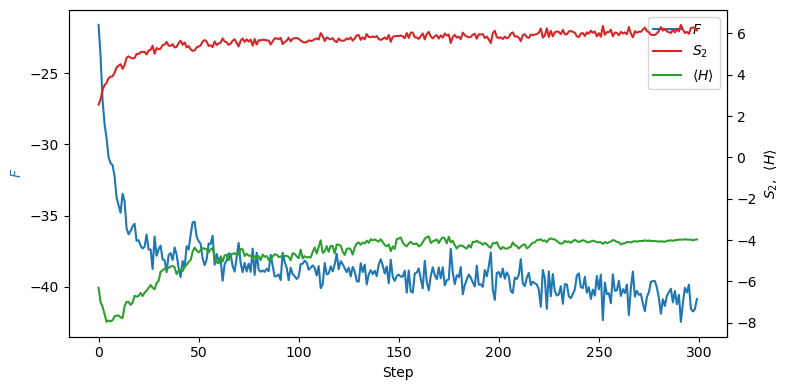

Best solution: S₂=6.412935, E=-3.972338, F=-42.449945


In [87]:
partition = list(range(N))
# sampler = nk.sampler.MetropolisLocal(hi_extended, n_chains=32)
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(
    hilbert=hi_extended,
    layers=1,
    features=16,
    activation=jax.nn.gelu,
)
# model = RBM_Z2(alpha=1, trivial_Z2=True)
vstate = nk.vqs.MCState(sampler, model, n_samples=40960, chunk_size=1024)
T = 5

n_steps = 300
lr = optax.warmup_cosine_decay_schedule(0.02, 0.02, 100, n_steps, 0.001)
# lr = optax.warmup_cosine_decay_schedule(0.05, 0.05, 80, n_steps, 0.001)
diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)

_,_,_,f_best,E_best,S_best = free_energy_minimize_SR_SGD(vstate, T, partition, H_extended, n_steps, learning_rate=lr, diag_shift=diag_shift, freq=20)
print(f"Best solution: S₂={S_best:.6f}, E={E_best:.6f}, F={f_best:.6f}")

Training at different temperatures

In [ ]:
#Minimizar F = <H> - TS₂ en función de T con scipy
T_array_scipy = np.linspace(0, 10, 60)
model = RBM_Z2(alpha=1, trivial_Z2=True)
# sampler = nk.sampler.ExactSampler(hilbert=hi_extended)

energy_results_scipy = []
entropy_results_scipy = []  
free_energy_results_scipy = []

for T in T_array_scipy:
    vstate = nk.vqs.FullSumState(hilbert=hi_extended, model=model) 
    # vstate = nk.vqs.MCState(sampler, model, n_samples=100000)
    result = free_energy_minimize_scipy(
        vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        method="L-BFGS-B",
        options={"maxiter": 50000},
        verbose=False
    )
    energy_results_scipy.append(result["best_energy"])
    entropy_results_scipy.append(result["best_entropy"])
    free_energy_results_scipy.append(result["best_F"])
    print(f"T={T:.3f} -- F={result["best_F"]:.6f}, E={result["best_energy"]:.6f}, S₂={result["best_entropy"]:.6f}, {result["result"].success}")

plt.plot(T_array_scipy, free_energy_results_scipy, label=r"$F$")
plt.plot(T_array_scipy, energy_results_scipy, label=r"$\langle H\rangle$")
plt.plot(T_array_scipy, entropy_results_scipy, label=r"$S_2$")
plt.legend()
plt.show()

In [ ]:
#Minimizar F = <H> - TS₂ en función de T
sampler = nk.sampler.MetropolisLocal(hi_extended)
model = RBM_Z2(alpha=1, trivial_Z2=True)

energy_results = []
entropy_results = []  
entropy_netket_results = []  
free_energy_results = []
all_histories = []

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")
    vstate = nk.vqs.MCState(sampler, model, n_samples=20000)
    n_steps = 400
    # lr = optax.warmup_cosine_decay_schedule(init_value=0.5, peak_value=1.5, warmup_steps=300, decay_steps=1000, end_value=0.5)
    # lr = 0.005
    lr = optax.cosine_decay_schedule(0.01, n_steps)
    # optimizer = optax.chain(optax.clip_by_global_norm(1.0),optax.adam(learning_rate=lr,b1=0.9,b2=0.999))
    # optimizer = optax.chain(optax.clip_by_global_norm(1.0),optax.sgd(learning_rate=lr,momentum=0.3))
    # optimizer = optax.sgd(lr, momentum=0.3)
    optimizer = optax.adam(lr)
    opt_state = optimizer.init(vstate.parameters)
    
    
    F_history, energy_history, entropy_history, best_F, best_energy, best_entropy = free_energy_minimize(
        vstate, optimizer, T, partition, H_extended, n_samples=vstate.n_samples, n_steps=n_steps,
        verbose=False, normalize_gradients=True, plot=False)
    
    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)
    
    all_histories.append({
        'T': T,
        'energy': energy_history,
        'entropy': entropy_history,
        'free_energy': F_history
    })
    
    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, "
          f"F={best_F:.4f}")

# ========== VISUALIZACIÓN ==========
plt.figure(figsize=(15, 10))

# 1. Resultados finales vs temperatura
plt.subplot(2, 3, 1)
plt.plot(T_array, energy_results, 'o-', label=r'$\langle H \rangle$')
plt.xlabel('T')
plt.ylabel('Energía')
plt.title('Energía vs Temperatura')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(T_array, entropy_results, 's-', label='S₂ (nuestra)')
plt.xlabel('T')
plt.ylabel('S₂')
plt.title('Entropía de Rényi-2 vs Temperatura')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(T_array, free_energy_results, 'd-', label='F = E - TS₂')
plt.xlabel('T')
plt.ylabel('F')
plt.title('Energía Libre vs Temperatura')
plt.grid(True, alpha=0.3)

# 2. Evolución durante optimización para algunas T seleccionadas
selected_T_indices = [0, len(T_array)//2, -1] 
for idx in selected_T_indices:
    T_val = T_array[idx]
    hist = all_histories[idx]
    
    plt.subplot(2, 3, 4)
    plt.plot(hist['energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('Energía')
    plt.title('Evolución de Energía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 5)
    plt.plot(hist['entropy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('S₂')
    plt.title('Evolución de Entropía')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 3, 6)
    plt.plot(hist['free_energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('F')
    plt.title('Evolución de Energía Libre')
    plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4).legend()
plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()
# ========== RESUMEN ==========
print("\n=== RESUMEN DE RESULTADOS ===")
print("Temperatura | Energía | S₂ (SWAP) | Energía Libre")
print("-" * 70)
for i, T in enumerate(T_array):
    print(f"{T:10.3f} | {energy_results[i]:8.4f} | {entropy_results[i]:12.4f} | {free_energy_results[i]:13.4f}")

enviar_grafica_telegram()

In [ ]:
# Minimizar F = <H> - T S₂ usando SR +SGD
T_array = np.linspace(0, 15, 40)

# sampler = nk.sampler.MetropolisLocal(hi_extended)
sampler = nk.sampler.ARDirectSampler(hi_extended)
# model = RBM_Z2(alpha=2, trivial_Z2=True)
model = nk.models.ARNNDense(hilbert=hi_extended,layers=1,features=16,activation=jax.nn.gelu)

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []
best_params = None

n_steps = 150

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    vstate = nk.vqs.MCState(
        sampler,
        model,
        n_samples=20000,
    )
    if best_params is not None:
        vstate.parameters = best_params

    free_energy_history, energy_history, entropy_history, best_F, best_energy, best_entropy = free_energy_minimize_SR_SGD(
        vstate=vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_steps=n_steps,
        verbose=True,
        isFullSum=False,
        plot=False,
        learning_rate=optax.warmup_cosine_decay_schedule(0.05, 0.05, 80, n_steps, 0.001),
        diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps),
    )
    best_params = vstate.parameters

    # Recalcular entropía final con lambda integral (más precisa)
    # best_entropy, _ = renyi2_entropy_and_grad_lambda_integral(vstate, partition, vstate.n_samples, 50)
    best_entropy = renyi2_entropy_sampled(vstate, partition, vstate.n_samples)
    best_F = best_energy - T*best_entropy

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append({
        "T": T,
        "energy": energy_history,
        "entropy": entropy_history,
        "free_energy": free_energy_history,
    })

    print(
        f"  Mejor resultado: "
        f"E={best_energy:.4f}, "
        f"S₂={best_entropy:.4f}, "
        f"F={best_F:.4f}"
    )

# ========== VISUALIZACIÓN ==========
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(T_array, energy_results, 'o-', label=r'$\langle H \rangle$')
plt.xlabel('T')
plt.ylabel('Energía')
plt.title('Energía vs Temperatura')
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(T_array, entropy_results, 's-', label='S₂ (nuestra)')
plt.xlabel('T')
plt.ylabel('S₂')
plt.title('Entropía de Rényi-2 vs Temperatura')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(T_array, free_energy_results, 'd-', label='F = E - TS₂')
plt.xlabel('T')
plt.ylabel('F')
plt.title('Energía Libre vs Temperatura')
plt.grid(True, alpha=0.3)

selected_T_indices = [0, len(T_array)//2, -1]
for idx in selected_T_indices:
    T_val = T_array[idx]
    hist = all_histories[idx]

    plt.subplot(2, 3, 4)
    plt.plot(hist['energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('Energía')
    plt.title('Evolución de Energía')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 5)
    plt.plot(hist['entropy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('S₂')
    plt.title('Evolución de Entropía')
    plt.grid(True, alpha=0.3)

    plt.subplot(2, 3, 6)
    plt.plot(hist['free_energy'], label=f'T={T_val:.2f}')
    plt.xlabel('Paso de optimización')
    plt.ylabel('F')
    plt.title('Evolución de Energía Libre')
    plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 4).legend()
plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()
plt.close()


enviar_grafica_telegram()

In [83]:
import json

data = {
    "T": [float(T) for T in T_array],
    "energy": [float(x) for x in energy_results],
    "entropy": [float(x) for x in entropy_results],
    "free_energy": [float(x) for x in free_energy_results],
}

with open(f"results_N{N}_vs_T.txt", "w") as f:
    json.dump(data, f, indent=2)


In [ ]:
#Comparar con scipy
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

ax1.scatter(T_array, free_energy_results, color="Blue", s=10, alpha=0.5, label="RBM")
ax1.plot(T_array_scipy, free_energy_results_scipy, color="Blue", label="Scipy")
ax1.set_xlabel("T")
ax1.set_ylabel("$F$")
ax1.set_title("Free energy")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.scatter(T_array, energy_results, color="Orange", s=10, alpha=0.5, label="RBM")
ax2.plot(T_array_scipy, energy_results_scipy, color="Orange", label="Scipy")
ax2.set_xlabel("T")
ax2.set_ylabel("$<H>$")
ax2.set_title("$Energy$")
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.scatter(T_array, entropy_results, color="Green", s=10, alpha=0.5, label="RBM")
ax3.plot(T_array_scipy, entropy_results_scipy, color="Green", label="Scipy")
ax3.set_xlabel("T")
ax3.set_ylabel("$S_2$")
ax3.set_title("Entanglement entropy")
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("output.png", dpi=200, bbox_inches="tight")
enviar_grafica_telegram()
plt.show()

In [ ]:
#Avisar de que ha acabado
import requests
import os
from datetime import datetime
from dotenv import load_dotenv
load_dotenv()

def enviar_grafica_telegram():

    bot_token = os.getenv("TELEGRAM_TOKEN")
    chat_id = os.getenv("TELEGRAM_ID")

    archivo = "output.png"

    if not os.path.exists(archivo):
        requests.post(
            f"https://api.telegram.org/bot{bot_token}/sendMessage",
            json={"chat_id": chat_id, "text": f"❌ No existe {archivo}"}
        )
        return False

    with open(archivo, "rb") as f:
        files = {"photo": f}

        caption = (
            "✅ Notebook completado\n"
            f"📅 {datetime.now():%Y-%m-%d %H:%M:%S}\n"
            f"📁 {os.path.getsize(archivo)/1024:.1f} KB"
        )

        response = requests.post(
            f"https://api.telegram.org/bot{bot_token}/sendPhoto",
            data={"chat_id": chat_id, "caption": caption},
            files=files
        )

    if not response.ok:
        print("Error Telegram:", response.text)

    return response.ok



In [81]:
def free_energy_minimize_SR_SGD(vstate, T, partition, Hamiltonian, n_steps=1000,
                                verbose=True, freq=50, plot=True,
                                learning_rate=None, diag_shift=None,
                                n_samples_sr=4096):
    if learning_rate is None:
        learning_rate = optax.warmup_cosine_decay_schedule(0.1, 0.1, 100, n_steps, 0.001)
    if diag_shift is None:
        diag_shift = optax.linear_schedule(1e-1, 1e-4, n_steps)

    sr = nk.optimizer.SR(diag_shift=diag_shift)

    subsystem_sites = jnp.array(partition, dtype=int)
    all_sites = jnp.arange(vstate.hilbert.size)
    complement_sites = jnp.setdiff1d(all_sites, subsystem_sites)
    n_samples_full = vstate.n_samples

    free_energy_history = []
    energy_history = []
    entropy_history = []
    best_F = float('inf')
    best_energy = None
    best_entropy = None
    best_params = None

    for step in range(n_steps):
        t0 = time.time()

        E, E_grad = vstate.expect_and_grad(Hamiltonian)

        key = jax.random.PRNGKey(step)
        all_samples = vstate.sample(n_samples=2 * n_samples_full).reshape(-1, vstate.hilbert.size)
        all_samples = jax.random.permutation(key, all_samples, axis=0)
        samples1 = all_samples[:n_samples_full]
        samples2 = all_samples[n_samples_full:]
        swapped1 = jnp.concatenate([samples2[:, subsystem_sites], samples1[:, complement_sites]], axis=1)
        swapped2 = jnp.concatenate([samples1[:, subsystem_sites], samples2[:, complement_sites]], axis=1)

        S2, S2_grad = _renyi2_loss_and_grad(
            vstate._apply_fun, vstate.parameters, vstate.model_state,
            samples1, samples2, swapped1, swapped2
        )

        F_grad = jax.tree_util.tree_map(lambda gE, gS: gE - T * gS, E_grad, S2_grad)

        vstate.n_samples = n_samples_sr
        delta = sr(vstate, F_grad, step)
        vstate.n_samples = n_samples_full

        lr = float(learning_rate(step) if callable(learning_rate) else learning_rate)
        vstate.parameters = jax.tree_util.tree_map(
            lambda p, d: p - lr * d, vstate.parameters, delta
        )

        F_val = float(E.mean.real) - T * float(S2)
        free_energy_history.append(F_val)
        energy_history.append(float(E.mean.real))
        entropy_history.append(float(S2))

        if F_val < best_F:
            best_F = F_val
            best_energy = float(E.mean.real)
            best_entropy = float(S2)
            best_params = vstate._parameters

        if step % freq == 0 and verbose:
            print(f"Step {step:4d} | E={float(E.mean.real):.6f}  S₂={float(S2):.6f}  "
                  f"F={F_val:.6f} | t={time.time()-t0:.3f}s")

    vstate.parameters = best_params

    if plot:
        fig, ax1 = plt.subplots(figsize=(8, 4))
        ax1.plot(free_energy_history, color="tab:blue", label=r"$F$")
        ax1.set_xlabel("Step")
        ax1.set_ylabel(r"$F$", color="tab:blue")
        ax2 = ax1.twinx()
        ax2.plot(entropy_history,  color="tab:red",   label=r"$S_2$")
        ax2.plot(energy_history,   color="tab:green", label=r"$\langle H\rangle$")
        ax2.set_ylabel(r"$S_2$,  $\langle H\rangle$")
        lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
        labs  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
        ax1.legend(lines, labs, loc="best")
        plt.tight_layout()
        plt.show()

    return (free_energy_history, energy_history, entropy_history,
            best_F, best_energy, best_entropy)

In [ ]:
partition = list(range(N))
sampler = nk.sampler.ARDirectSampler(hi_extended)
model = nk.models.ARNNDense(hilbert=hi_extended, layers=1, features=16, activation=jax.nn.gelu)
vstate = nk.vqs.MCState(sampler, model, n_samples=20480, chunk_size=1024)

T_array = np.linspace(0, 15, 40)
n_steps = 150

energy_results = []
entropy_results = []
free_energy_results = []
all_histories = []
best_params = None

for T_idx, T in enumerate(tqdm(T_array, desc="Temperaturas")):
    print(f"\n=== Temperatura T = {T:.3f} ===")

    jax.clear_caches()  
    vstate.init_parameters()
    vstate.sampler_state = vstate.sampler.reset(vstate._apply_fun, vstate.parameters) 
    if best_params is not None:
        vstate.parameters = best_params

    free_energy_history, energy_history, entropy_history, best_F, best_energy, best_entropy = free_energy_minimize_SR_SGD(
        vstate=vstate,
        T=T,
        partition=partition,
        Hamiltonian=H_extended,
        n_steps=n_steps,
        verbose=True,
        plot=False,
        learning_rate=optax.warmup_cosine_decay_schedule(0.05, 0.05, 80, n_steps, 0.001),
        diag_shift=optax.linear_schedule(1e-1, 1e-4, n_steps),
    )
    best_params = vstate.parameters

    # Recalcular entropía final 
    best_entropy = float(renyi2_entropy_sampled(vstate, partition, vstate.n_samples))
    best_F = best_energy - T * best_entropy

    energy_results.append(best_energy)
    entropy_results.append(best_entropy)
    free_energy_results.append(best_F)

    all_histories.append({
        "T": T,
        "energy": energy_history,
        "entropy": entropy_history,
        "free_energy": free_energy_history,
    })

    print(f"  Mejor resultado: E={best_energy:.4f}, S₂={best_entropy:.4f}, F={best_F:.4f}")

# Visualización
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
plt.plot(T_array, energy_results, 'o-')
plt.xlabel('T'); plt.ylabel('Energía'); plt.title('Energía vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 2)
plt.plot(T_array, entropy_results, 's-')
plt.xlabel('T'); plt.ylabel('S₂'); plt.title('Entropía de Rényi-2 vs Temperatura'); plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 3)
plt.plot(T_array, free_energy_results, 'd-')
plt.xlabel('T'); plt.ylabel('F'); plt.title('Energía Libre vs Temperatura'); plt.grid(True, alpha=0.3)

for idx in [0, len(T_array)//2, -1]:
    hist = all_histories[idx]
    T_val = T_array[idx]
    plt.subplot(2, 3, 4); plt.plot(hist['energy'], label=f'T={T_val:.2f}')
    plt.subplot(2, 3, 5); plt.plot(hist['entropy'], label=f'T={T_val:.2f}')
    plt.subplot(2, 3, 6); plt.plot(hist['free_energy'], label=f'T={T_val:.2f}')

for i in [4, 5, 6]:
    plt.subplot(2, 3, i)
    plt.xlabel('Paso'); plt.legend(); plt.grid(True, alpha=0.3)
plt.subplot(2, 3, 4); plt.ylabel('Energía'); plt.title('Evolución de Energía')
plt.subplot(2, 3, 5); plt.ylabel('S₂'); plt.title('Evolución de Entropía')
plt.subplot(2, 3, 6); plt.ylabel('F'); plt.title('Evolución de Energía Libre')

plt.tight_layout()
plt.savefig("output.png", dpi=200, bbox_inches="tight")
plt.show()

Temperaturas:   0%|          | 0/40 [00:00<?, ?it/s]


=== Temperatura T = 0.000 ===
Step    0 | E=-15.018997  S₂=0.011539  F=-15.018997 | t=6.496s


Temperaturas:   0%|          | 0/40 [00:08<?, ?it/s]


UnexpectedTracerError: Encountered an unexpected tracer. A function transformed by JAX had a side effect, allowing for a reference to an intermediate value with type uint32[2] wrapped in a DynamicJaxprTracer to escape the scope of the transformation.
JAX transformations require that functions explicitly return their outputs, and disallow saving intermediate values to global state.
The function being traced when the value leaked was training_step at /tmp/ipykernel_5855/1816476309.py:17 traced for jit.
------------------------------
The leaked intermediate value was created on line /tmp/ipykernel_5855/1816476309.py:33:16 (free_energy_minimize_SR_SGD.<locals>.training_step). 
------------------------------
When the value was created, the final 5 stack frames (most recent last) excluding JAX-internal frames were:
------------------------------
<frozen runpy>:198:11 (_run_module_as_main)
<frozen runpy>:88:4 (_run_code)
/tmp/ipykernel_5855/872374922.py:25:94 (<module>)
/tmp/ipykernel_5855/18